In [14]:
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
df_complaints=pd.read_csv("data/complaints20_25_original.csv")
print(df_complaints.isna().sum())
df_complaints = df_complaints.drop(columns=["agency_name"])
df_complaints.head()

unique_key          0
created_date        0
agency_name         0
complaint_type      0
incident_zip        0
council_district    0
borough             0
dtype: int64


,unique_key,created_date,complaint_type,incident_zip,council_district,borough
0,67350845,2025-12-31 23:57:56,HEAT/HOT WATER,11229,46,BROOKLYN
1,67347338,2025-12-31 23:54:46,HEAT/HOT WATER,11239,42,BROOKLYN
2,67350847,2025-12-31 23:54:42,HEAT/HOT WATER,10040,10,MANHATTAN
3,67346000,2025-12-31 23:54:41,HEAT/HOT WATER,10463,10,MANHATTAN
4,67349568,2025-12-31 23:54:14,HEAT/HOT WATER,10454,8,BRONX


In [16]:
print(f"Number of complaints: {len(df_complaints)}")

df_complaints["created_date"]=pd.to_datetime(df_complaints["created_date"]) #add smth for errors
print(f"Date range: {df_complaints["created_date"].min()}, {df_complaints["created_date"].max()}")

unique_comp=list(df_complaints["complaint_type"].unique())
print(f"Number of types of complaints: {len(unique_comp)}")
print(f"Types of compaints: {unique_comp}")

print(f"Number of different zipcodes: {len(df_complaints["incident_zip"].unique())}")
print(f"Number of different council districts: {len(df_complaints["council_district"].unique())}")
print(f"Number of different boroughs: {len(df_complaints["borough"].unique())}")

Number of complaints: 2468050
Date range: 2021-01-01 00:01:14, 2025-12-31 23:57:56
Number of types of complaints: 5
Types of compaints: ['HEAT/HOT WATER', 'PLUMBING', 'WATER LEAK', 'UNSANITARY CONDITION', 'ELECTRIC']
Number of different zipcodes: 211
Number of different council districts: 51
Number of different boroughs: 5


In [17]:
print(f"Number of complaints per type:\n {df_complaints["complaint_type"].value_counts()}")

comp_borough=df_complaints["borough"].value_counts()
print(f"\nNumber of complaints per borough:\n {comp_borough}")

Number of complaints per type:
 complaint_type
HEAT/HOT WATER          1275874
UNSANITARY CONDITION     544853
PLUMBING                 307724
WATER LEAK               201971
ELECTRIC                 137628
Name: count, dtype: int64

Number of complaints per borough:
 borough
BRONX            860262
BROOKLYN         704758
MANHATTAN        535965
QUEENS           325246
STATEN ISLAND     41819
Name: count, dtype: int64


The number of complaints per borough might be influenced by how many people live there. Lets take that into account and calculate the number of complaints per 1000 people in each borough.

In [18]:
borough_order = ["BRONX", "BROOKLYN", "MANHATTAN", "QUEENS", "STATEN ISLAND"]
comp_borough = df_complaints["borough"].value_counts().reindex(borough_order)
borough_pop = pd.Series([1446788, 2648452, 1638281, 2330295, 487155],index=borough_order)
complaints_per_1000 = (comp_borough / borough_pop) * 1000
df_rates = pd.DataFrame({
    "complaints": comp_borough,
    "population": borough_pop,
    "complaints_per_1000": complaints_per_1000
})
df_rates

,complaints,population,complaints_per_1000
BRONX,860262,1446788,594.601282
BROOKLYN,704758,2648452,266.101859
MANHATTAN,535965,1638281,327.150837
QUEENS,325246,2330295,139.572887
STATEN ISLAND,41819,487155,85.843315


In [19]:
df_complaints["year"]=df_complaints["created_date"].dt.year
year_type = df_complaints.groupby(["year", "complaint_type"]).size().unstack(fill_value=0)
year_type

complaint_type,ELECTRIC,HEAT/HOT WATER,PLUMBING,UNSANITARY CONDITION,WATER LEAK
year,,,,,
2021,23547,199547,51903,90369,36549
2022,26971,264380,57544,99240,35676
2023,28402,231308,62860,116686,46188
2024,28123,264719,65884,120837,45166
2025,30585,315920,69533,117721,38392


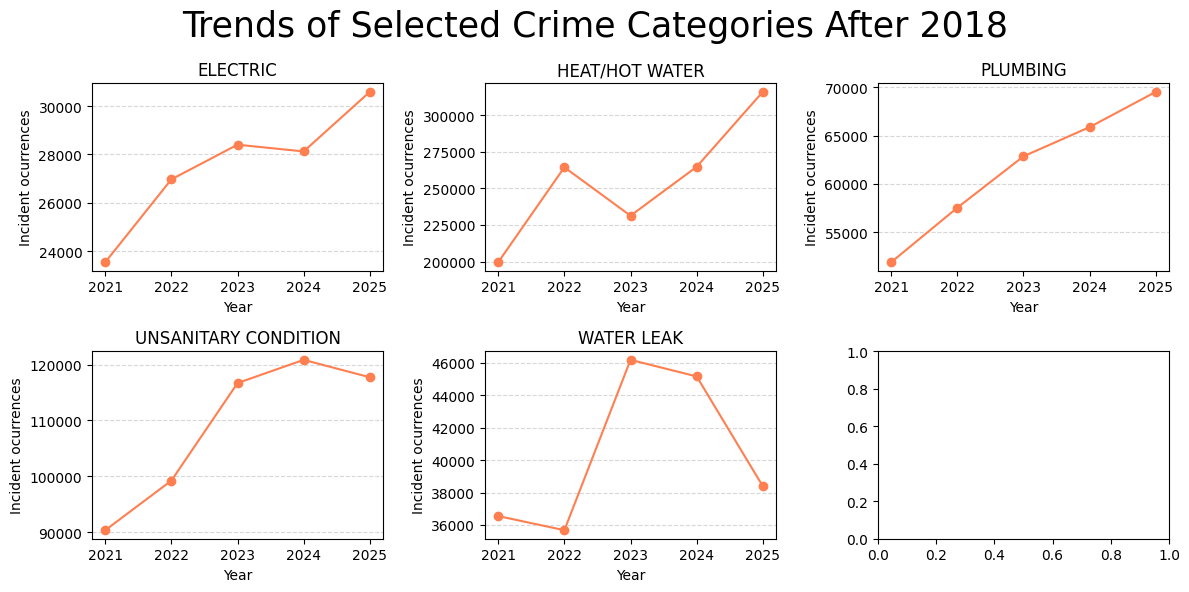

In [20]:
comp_types = year_type.columns.tolist()
years = sorted(year_type.index.tolist())

fig, axes = plt.subplots(2, 3, figsize=(12, 6), )
axes = axes.flatten() 

for i in range(len(comp_types)):
    cat=comp_types[i]
    values=year_type[cat].values

    axes[i].plot(years, values, color="coral", marker='o')
    axes[i].set_title(cat)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("Incident ocurrences")
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("Trends of Selected Crime Categories After 2018", fontsize=25)
plt.tight_layout()
plt.show()

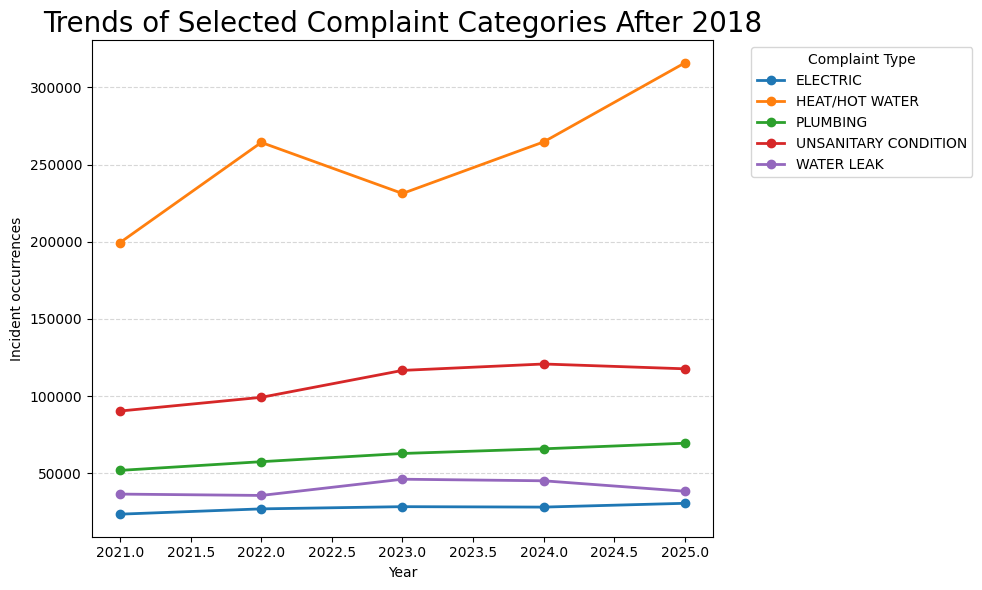

In [21]:
plt.figure(figsize=(10, 6))

for cat in comp_types:
    plt.plot(
        years,
        year_type[cat].values,
        marker='o',
        linewidth=2,
        label=cat
    )

plt.title("Trends of Selected Complaint Categories After 2018", fontsize=20)
plt.xlabel("Year")
plt.ylabel("Incident occurrences")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Complaint Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [22]:
year_boro = df_complaints.groupby(["year", "borough"]).size().unstack(fill_value=0)
year_boro

borough,BRONX,BROOKLYN,MANHATTAN,QUEENS,STATEN ISLAND
year,,,,,
2021,138143,119800,85022,51747,7203
2022,170131,139217,102777,63158,8528
2023,168318,138601,105276,63823,9426
2024,184587,147865,111768,72283,8226
2025,199083,159275,131122,74235,8436


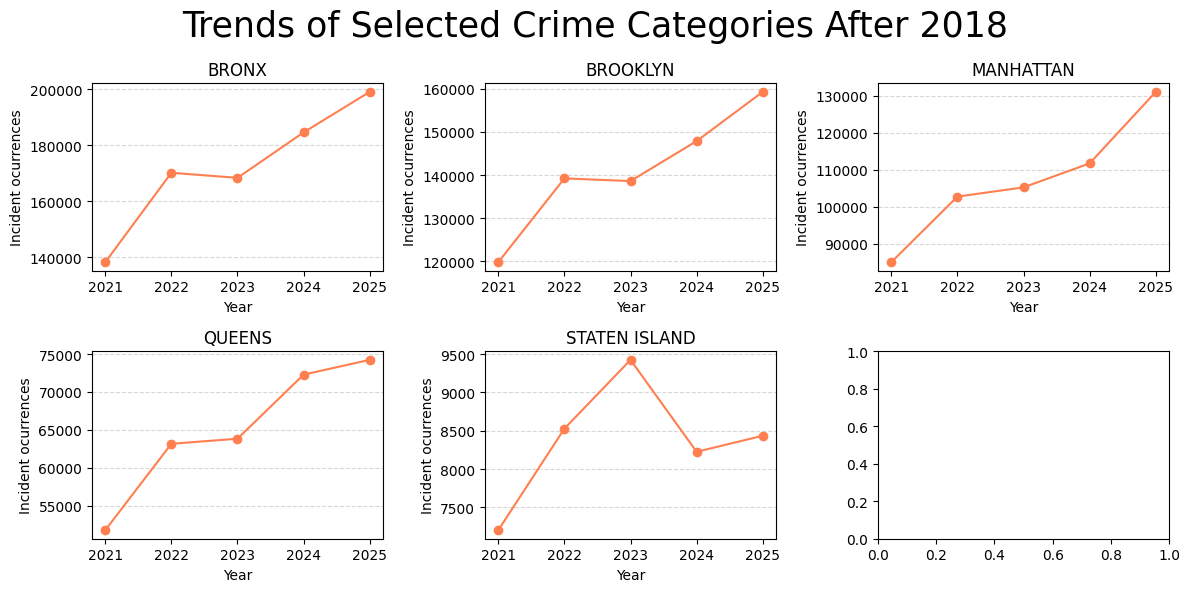

In [23]:
boroughs = year_boro.columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(12, 6), )
axes = axes.flatten() 

for i in range(len(boroughs)):
    cat=boroughs[i]
    values=year_boro[cat].values

    axes[i].plot(years, values, color="coral", marker='o')
    axes[i].set_title(cat)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("Incident ocurrences")
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("Trends of Selected Crime Categories After 2018", fontsize=25)
plt.tight_layout()
plt.show()

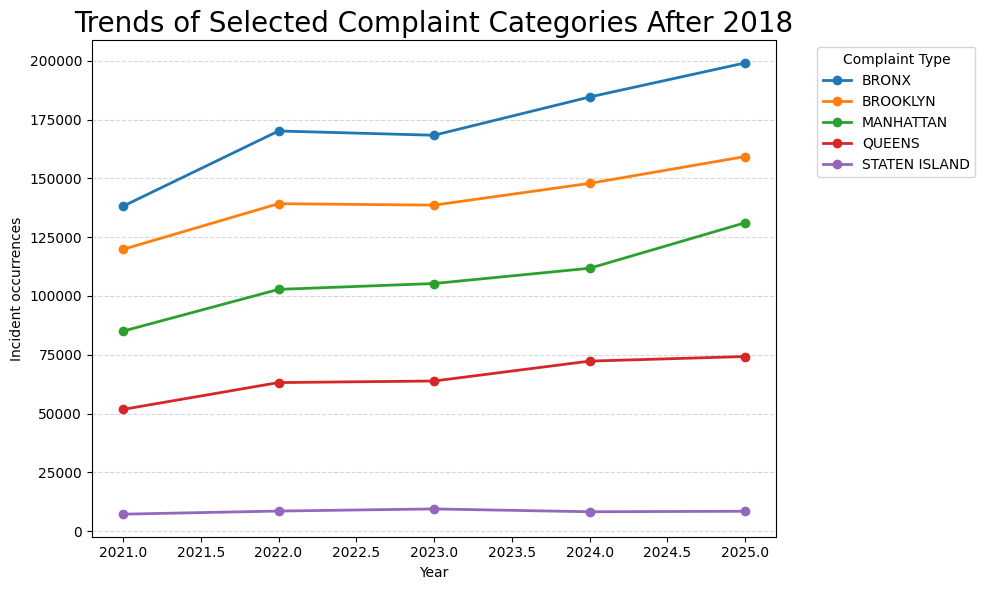

In [24]:
plt.figure(figsize=(10, 6))

for cat in boroughs:
    plt.plot(
        years,
        year_boro[cat].values,
        marker='o',
        linewidth=2,
        label=cat
    )

plt.title("Trends of Selected Complaint Categories After 2018", fontsize=20)
plt.xlabel("Year")
plt.ylabel("Incident occurrences")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Complaint Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()